In [3]:
from pathlib import Path
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [4]:
RAW_PATH = Path("../data/raw/freshretailnet_train_sample.parquet")

df = pd.read_parquet(RAW_PATH)
print("Dataframe shape: ", df.shape)
df.head(3)

Dataframe shape:  (10000, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, ...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,1,0,2.0942,15.91,76.47,1.73


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city_id              10000 non-null  int64  
 1   store_id             10000 non-null  int64  
 2   management_group_id  10000 non-null  int64  
 3   first_category_id    10000 non-null  int64  
 4   second_category_id   10000 non-null  int64  
 5   third_category_id    10000 non-null  int64  
 6   product_id           10000 non-null  int64  
 7   dt                   10000 non-null  str    
 8   sale_amount          10000 non-null  float64
 9   hours_sale           10000 non-null  object 
 10  stock_hour6_22_cnt   10000 non-null  int32  
 11  hours_stock_status   10000 non-null  object 
 12  discount             10000 non-null  float64
 13  holiday_flag         10000 non-null  int32  
 14  activity_flag        10000 non-null  int32  
 15  precpt               10000 non-null  float64
 16

In [6]:
df.isna().sum()

city_id                0
store_id               0
management_group_id    0
first_category_id      0
second_category_id     0
third_category_id      0
product_id             0
dt                     0
sale_amount            0
hours_sale             0
stock_hour6_22_cnt     0
hours_stock_status     0
discount               0
holiday_flag           0
activity_flag          0
precpt                 0
avg_temperature        0
avg_humidity           0
avg_wind_level         0
dtype: int64

In [7]:
print(df['sale_amount'].max())
print(df['sale_amount'].min())

21.3
0.0


**hours sale inspection**

In [8]:
print(type(df.loc[0, 'hours_sale']))
print(df.loc[0, 'hours_sale'])
print(len(df.loc[0,'hours_sale']))
print(df["hours_sale"].apply(len).value_counts())

<class 'numpy.ndarray'>
[0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0. ]
24
hours_sale
24    10000
Name: count, dtype: int64


In [9]:
# Convert string to a datetime object
df['dt'] = pd.to_datetime(df['dt'], format='%Y-%m-%d')
df.head(2)

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, ...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,3.0190,15.08,76.56,1.71


In [10]:
# smoke test

row = df.iloc[0]

hourly_demand = pd.DataFrame({
    'dt':row['dt'],
    'hour':range(24),
    'demand':row['hours_sale']
})

hourly_demand.head(10)

,dt,hour,demand
0,2024-03-28,0,0.0
1,2024-03-28,1,0.0
2,2024-03-28,2,0.0
3,2024-03-28,3,0.0
4,2024-03-28,4,0.0
5,2024-03-28,5,0.0
6,2024-03-28,6,0.0
7,2024-03-28,7,0.1
8,2024-03-28,8,0.0
9,2024-03-28,9,0.0


plan:

1. explode the hours_sale column first
2. we will get demand for each date, hour, product, store
3. then aggregate demand based on date per hour

In [11]:
# explode on dataframe
df_hourly = df.copy()
df_hourly['hour'] = df_hourly['hours_sale'].apply(lambda x: list(range(len(x))))
df_hourly = df_hourly.explode(['hours_sale','hour'], ignore_index=True)
df_hourly.head(2)

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,hour
0,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,0
1,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,1


In [12]:
# check number of rows for each city, store, product, and date. should be 24 because of 24 hours
df_hourly[(df_hourly['city_id']==0) & (df_hourly['store_id']==0) & (df_hourly['product_id']==38) & (df_hourly['dt']=='2024-03-28')].shape

(24, 20)

In [13]:
print(df_hourly.shape)
df_hourly.head()

(240000, 20)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,hour
0,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,0
1,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,1
2,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,2
3,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,3
4,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,4


## 1st version : granularity = date + hour

**demand = sum of hourly sales across all products/stores**

**example**

datetime              demand

2023-01-01 00:00      sum of all product-store demand at hour 0

2023-01-01 01:00      sum of all product-store demand at hour 1

2023-01-01 02:00      sum of all product-store demand at hour 2

In [14]:
# df_hourly_group = df_hourly.groupby(['dt','hour']).agg(total_hourly_demand=('hours_sale', 'sum'))
# df_hourly_group

In [15]:
df_hourly['total_hourly_demand'] = df_hourly.groupby(['dt','hour'])['hours_sale'].transform('sum')
print(df_hourly.shape)
df_hourly.head(5)

(240000, 21)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,...,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,hour,total_hourly_demand
0,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,0,0.3
1,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,1,0.0
2,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,2,0.0
3,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,3,0.2
4,0,0,0,5,6,65,38,2024-03-28,0.1,0.0,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97,4,0.2


### dataframe for model

In [16]:
df_hourly['hours_sale'] = df_hourly['hours_sale'].astype(float)

In [17]:
hourly_demand = (
    df_hourly.groupby(['dt','hour'], as_index=False).agg(demand=('hours_sale',sum))
)

hourly_demand['dt'] = pd.to_datetime(hourly_demand['dt'])
hourly_demand['datetime'] = hourly_demand['dt'] + pd.to_timedelta(hourly_demand['hour'], unit='h')
hourly_demand = hourly_demand[['datetime','dt','hour','demand']]
hourly_demand

,datetime,dt,hour,demand
0,2024-03-28 00:00:00,2024-03-28,0,0.30
1,2024-03-28 01:00:00,2024-03-28,1,0.00
2,2024-03-28 02:00:00,2024-03-28,2,0.00
3,2024-03-28 03:00:00,2024-03-28,3,0.20
4,2024-03-28 04:00:00,2024-03-28,4,0.20
...,...,...,...,...
2155,2024-06-25 19:00:00,2024-06-25,19,4.92
2156,2024-06-25 20:00:00,2024-06-25,20,4.80
2157,2024-06-25 21:00:00,2024-06-25,21,2.10
2158,2024-06-25 22:00:00,2024-06-25,22,2.10


In [18]:
hourly_demand["hour"].value_counts().sort_index()

hour
0     90
1     90
2     90
3     90
4     90
5     90
6     90
7     90
8     90
9     90
10    90
11    90
12    90
13    90
14    90
15    90
16    90
17    90
18    90
19    90
20    90
21    90
22    90
23    90
Name: count, dtype: int64

In [19]:
hourly_demand.duplicated(subset=["datetime"]).sum()

np.int64(0)

check timeframe

In [20]:
hourly_demand["datetime"].min(), hourly_demand["datetime"].max()

(Timestamp('2024-03-28 00:00:00'), Timestamp('2024-06-25 23:00:00'))

check missing hours

In [21]:
full_range = pd.date_range(
    start=hourly_demand["datetime"].min(),
    end=hourly_demand["datetime"].max(),
    freq="h"
)

missing_hours = full_range.difference(hourly_demand["datetime"])

len(missing_hours)

0

sanity check

In [22]:
hourly_demand["demand"].describe()

count    2160.000000
mean        4.568574
std         4.146386
min         0.000000
25%         1.000000
50%         3.900000
75%         7.000000
max        25.600000
Name: demand, dtype: float64

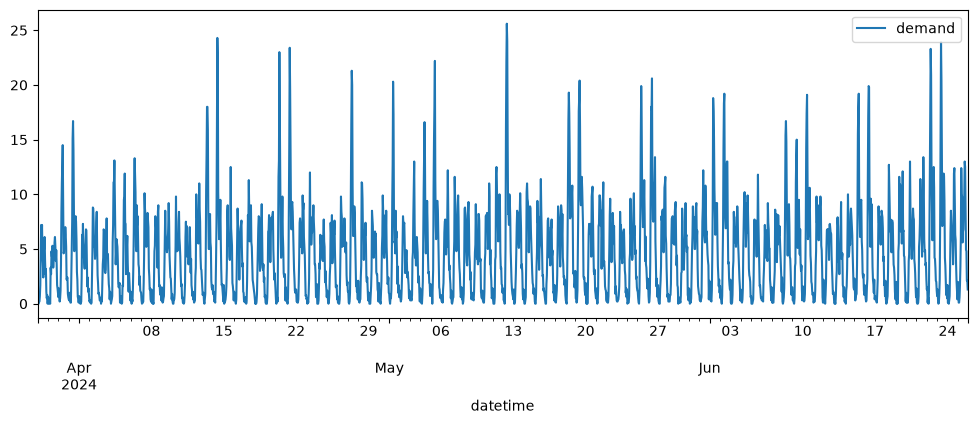

In [30]:
VIZ_PATH = Path("../outputs/figures")
hourly_demand.plot(x="datetime", y="demand", figsize=(12, 4))
plt.savefig(f'{VIZ_PATH}/hourly_demand.png')

In [25]:
PROCESSED_PATH = Path("../data/processed/hourly_demand_sample.parquet")

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
hourly_demand.to_parquet(PROCESSED_PATH, index=False)